# Drifting ICNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Tuple, List

### Hyperparameters

In [ ]:
METHODS = ["kernel", "ot_direct", "npf"]
TARGET = "four_gaussians"
NUM_ITERS = 3000
BATCH_SIZE = 512
LR = 3e-4
INNER_STEPS = 10
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH = "results/icnn_drifting_comparison.png"

# NPF (Vesseron & Cuturi, 2024) parameterization replaces the plain ICNN.
NPF_HIDDEN_DIMS = [128, 128, 128, 64, 32]
NPF_OUTER_RANK = 4
NPF_INNER_RANK = 1
NPF_ACTIVATION = "softplus"
NPF_SOFTPLUS_BETA = 1.0
NPF_INIT_EPS = 1e-2
NPF_INNER_LR = 1e-2
NPF_GRAD_CLIP = 5.0
SINKHORN_REG = 0.05


### NPF: Input Convex Network parameterization
Imported from `npf_drift.py` (shared with MNIST and gaussian-init ablation notebooks). The kernel-based baseline is kept inline below because it is not part of the NPF module.

In [ ]:
# NPF + helpers come from the shared module. Kernel baseline stays inline.
from npf_drift import (
    NPFInputConvexPotential,
    NPFDriftField,
    barycentric_target_simple,
    sinkhorn_simple,
    count_parameters,
)


def compute_V_kernel(x_gen: torch.Tensor, y_pos: torch.Tensor,
                     tau_list: Tuple[float, ...] = (0.02, 0.05, 0.2)):
    """
    Compute the drifting field V(x) following Algorithm 2 / Eq. 11 of the paper.

    Returns V (detached), such that the training loss is:
        target = sg(x_gen + V)
        loss = ||x_gen - target||²

    The loss value equals ||V||², which DECREASES as q → p.
    """
    N, D = x_gen.shape
    M = y_pos.shape[0]
    x = x_gen.detach()
    y = y_pos.detach()

    # Targets: [negatives (=generated), positives (=data)]
    targets = torch.cat([x, y], dim=0)  # [N+M, D]

    # ── Pairwise ℓ₂ distances ──
    dist = torch.cdist(x, targets)  # [N, N+M]

    # ── Distance normalization (Appendix A.6) ──
    # Normalize so mean pairwise distance ≈ √D
    scale = dist.mean().clamp(min=1e-6)
    dist_normed = dist * (np.sqrt(D) / scale)

    # ── Self-masking ──
    diag_mask = torch.zeros(N, N + M, device=x.device)
    diag_mask[:, :N] = torch.eye(N, device=x.device)
    dist_normed = dist_normed + diag_mask * 100.0

    # ── Force accumulation (NO per-temperature normalization) ──
    V = torch.zeros_like(x)

    for tau in tau_list:
        logits = -dist_normed / tau

        # Double softmax (paper's Alg. 2: softmax over y, then over x)
        aff_row = torch.softmax(logits, dim=-1)
        aff_col = torch.softmax(logits, dim=-2)
        affinity = torch.sqrt((aff_row * aff_col).clamp(min=1e-6))

        aff_neg = affinity[:, :N]      # negative affinities
        aff_pos = affinity[:, N:]      # positive affinities
        sum_pos = aff_pos.sum(-1, keepdim=True)
        sum_neg = aff_neg.sum(-1, keepdim=True)

        # Drifting coefficients: attract by positives, repel by negatives
        r_coeff_neg = -aff_neg * sum_pos
        r_coeff_pos = aff_pos * sum_neg
        R_coeff = torch.cat([r_coeff_neg, r_coeff_pos], dim=1)  # [N, N+M]

        # Force = weighted combination of (target - x) vectors
        force_R = R_coeff @ targets - R_coeff.sum(-1, keepdim=True) * x
        V = V + force_R  # Raw force, NO normalization

    return V.detach()


### NPF-based V (Sinkhorn OT displacement) and direct OT baseline

In [ ]:
def compute_V_ot_direct(x_gen: torch.Tensor, y_pos: torch.Tensor,
                        reg: float = SINKHORN_REG):
    """Direct OT displacement V(x) = T_Sinkhorn(x) - x."""
    x = x_gen.detach()
    y = y_pos.detach()
    y_target = barycentric_target_simple(x, y, reg=reg, num_iters=100)
    return (y_target - x).detach()


def make_npf_target_fn(reg: float):
    """Closure over reg for NPFDriftField.sinkhorn_target_fn."""
    return lambda x, y: barycentric_target_simple(x, y, reg=reg, num_iters=100)


def make_npf_drift(dim: int = 2, hidden_dims=None,
                   inner_steps: int = INNER_STEPS,
                   sinkhorn_reg: float = SINKHORN_REG,
                   inner_lr: float = NPF_INNER_LR,
                   init_eps: float = NPF_INIT_EPS,
                   outer_rank: int = NPF_OUTER_RANK,
                   inner_rank: int = NPF_INNER_RANK,
                   activation: str = NPF_ACTIVATION,
                   softplus_beta: float = NPF_SOFTPLUS_BETA,
                   grad_clip: float = NPF_GRAD_CLIP) -> NPFDriftField:
    """Construct an identity-init NPFDriftField with this notebook's defaults."""
    if hidden_dims is None:
        hidden_dims = NPF_HIDDEN_DIMS
    return NPFDriftField(
        dim=dim,
        hidden_dims=hidden_dims,
        outer_rank=outer_rank,
        inner_rank=inner_rank,
        activation=activation,
        softplus_beta=softplus_beta,
        init_eps=init_eps,
        inner_steps=inner_steps,
        inner_lr=inner_lr,
        grad_clip=grad_clip,
        sinkhorn_reg=sinkhorn_reg,
        sinkhorn_iters=100,
        sinkhorn_target_fn=make_npf_target_fn(sinkhorn_reg),
        init_mode="identity",
    )


### Generator

In [5]:
class ToyGenerator(nn.Module):
    """
    Small MLP: ε ∈ R² → x ∈ R².

    The initial output distribution must span the target range.
    If the initial generator output is concentrated (std << target range),
    the kernel V gives near-zero force (all data points equidistant).
    """
    def __init__(self, noise_dim=2, data_dim=2, hidden_dim=256, output_scale=2.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, data_dim),
        )
        # Initialize so output has std ≈ output_scale
        # We need to account for variance propagation through the MLP
        self._init_output_scale(output_scale)

    def _init_output_scale(self, target_std):
        """Initialize so the output std ≈ target_std."""
        with torch.no_grad():
            # Check current output scale
            test_input = torch.randn(1000, 2)
            test_output = self.net(test_input)
            current_std = test_output.std().item()
            if current_std > 1e-6:
                scale_factor = target_std / current_std
                # Scale only the last layer to avoid disrupting internal representations
                self.net[-1].weight.mul_(scale_factor)
                self.net[-1].bias.mul_(scale_factor)

    def forward(self, eps):
        return self.net(eps)

### Target Distributions

In [6]:
def sample_bimodal(n, device):
    mix = torch.rand(n, device=device) < 0.5
    x = torch.randn(n, 2, device=device) * 0.4
    x[mix, 0] += 2.0
    x[~mix, 0] -= 2.0
    return x

def sample_ring(n, device):
    theta = 2 * np.pi * torch.rand(n, device=device)
    r = 2.0 + 0.2 * torch.randn(n, device=device)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], -1)

def sample_four_gaussians(n, device):
    c = torch.tensor([[-2, -2], [-2, 2], [2, -2], [2, 2]],
                      device=device, dtype=torch.float32)
    return c[torch.randint(0, 4, (n,), device=device)] + 0.3 * torch.randn(n, 2, device=device)

### Training Loop

In [ ]:
def train(method='kernel', target='bimodal', num_iters=3000, batch_size=512,
          lr=3e-4, inner_steps=10, seed=42,
          device='cuda' if torch.cuda.is_available() else 'cpu'):

    torch.manual_seed(seed)
    device = torch.device(device)
    samplers = dict(bimodal=sample_bimodal, ring=sample_ring,
                    four_gaussians=sample_four_gaussians)
    sample_target = samplers[target]

    gen = ToyGenerator(hidden_dim=256, output_scale=2.0).to(device)
    gen_optim = optim.Adam(gen.parameters(), lr=lr)


    with torch.no_grad():
        test_out = gen(torch.randn(1000, 2, device=device))
        print(f"  [{method}] Initial output: mean={test_out.mean(0).cpu().numpy()}, "
              f"std={test_out.std(0).cpu().numpy()}")

    npf_drift = None
    if method == 'npf':
        npf_drift = make_npf_drift(
            dim=2, hidden_dims=NPF_HIDDEN_DIMS,
            inner_steps=inner_steps,
            sinkhorn_reg=SINKHORN_REG,
        ).to(device)
        with torch.no_grad():
            tz = torch.randn(8, 2, device=device)
            err = (npf_drift.psi.gradient(tz, False) - tz).abs().max().item()
            print(f"  [init check] max |T(z)-z| = {err:.2e}")

    losses, v_norms, snapshots = [], [], []

    for it in range(num_iters):
        eps = torch.randn(batch_size, 2, device=device)
        y_pos = sample_target(batch_size, device)
        x_gen = gen(eps)

        if method == 'kernel':
            V = compute_V_kernel(x_gen, y_pos, tau_list=(0.02, 0.05, 0.2))
        elif method == 'ot_direct':
            V = compute_V_ot_direct(x_gen, y_pos, reg=SINKHORN_REG)
        else:
            V = npf_drift.compute_V(x_gen, y_pos)

        # Drifting loss
        # L = ||f(ε) - sg(f(ε) + V(f(ε)))||²
        target_pts = (x_gen.detach() + V).detach()  # frozen target
        loss = ((x_gen - target_pts) ** 2).mean()
        v_norm = (V ** 2).mean().item()  # ||V||² — should decrease

        gen_optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
        gen_optim.step()

        losses.append(loss.item())
        v_norms.append(v_norm)

        if it % (num_iters // 8) == 0 or it == num_iters - 1:
            with torch.no_grad():
                snap_x = gen(torch.randn(1000, 2, device=device)).cpu().numpy()
            snapshots.append((it, snap_x))
            print(f"[{method}] iter {it:5d} | loss: {loss.item():.6f} | "
                  f"||V||²: {v_norm:.6f}")

    return dict(losses=losses, v_norms=v_norms, snapshots=snapshots,
                method=method, target=target)


In [8]:
results = []
for m in METHODS:
    print(f"\n{'=' * 60}\nTraining: {m}\n{'=' * 60}")
    results.append(train(
        method=m, target=TARGET, num_iters=NUM_ITERS,
        batch_size=BATCH_SIZE, lr=LR,
        inner_steps=INNER_STEPS, seed=SEED, device=DEVICE))


Training: kernel
  [kernel] Initial output: mean=[-4.9333467 -4.749685 ], std=[2.1921108 1.9367473]
[kernel] iter     0 | loss: 113.228256 | ||V||²: 113.228256
[kernel] iter   375 | loss: 3.828488 | ||V||²: 3.828488
[kernel] iter   750 | loss: 5.722761 | ||V||²: 5.722761
[kernel] iter  1125 | loss: 4.601583 | ||V||²: 4.601583
[kernel] iter  1500 | loss: 4.432547 | ||V||²: 4.432547
[kernel] iter  1875 | loss: 2.274434 | ||V||²: 2.274434
[kernel] iter  2250 | loss: 5.452107 | ||V||²: 5.452107
[kernel] iter  2625 | loss: 4.015389 | ||V||²: 4.015389
[kernel] iter  2999 | loss: 4.466640 | ||V||²: 4.466640

Training: ot_direct
  [ot_direct] Initial output: mean=[-4.9333467 -4.749685 ], std=[2.1921108 1.9367473]
[ot_direct] iter     0 | loss: 26.790279 | ||V||²: 26.790279
[ot_direct] iter   375 | loss: 0.346947 | ||V||²: 0.346947
[ot_direct] iter   750 | loss: 0.265784 | ||V||²: 0.265784
[ot_direct] iter  1125 | loss: 0.238479 | ||V||²: 0.238479
[ot_direct] iter  1500 | loss: 0.172064 | ||V|

### Visualization

In [9]:
def plot_results(results_list, target='bimodal', device='cpu',
                 save=False, save_path='icnn_drifting_comparison.png'):
    n_methods = len(results_list)
    n_snaps = len(results_list[0]['snapshots'])
    fig = plt.figure(figsize=(4 * n_snaps + 4, 4 * n_methods + 4))
    gs = GridSpec(n_methods + 1, n_snaps + 1, figure=fig, hspace=0.3, wspace=0.3)

    samplers = dict(bimodal=sample_bimodal, ring=sample_ring,
                    four_gaussians=sample_four_gaussians)
    y_gt = samplers[target](2000, torch.device('cpu')).numpy()

    for row, res in enumerate(results_list):
        for col, (it, snap) in enumerate(res['snapshots']):
            ax = fig.add_subplot(gs[row, col])
            ax.scatter(y_gt[:, 0], y_gt[:, 1], s=1, alpha=.3, c='blue', label='target $p$')
            ax.scatter(snap[:, 0], snap[:, 1], s=1, alpha=.3, c='orange', label='generated $q$')
            ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect('equal')
            ax.set_title(f'iter {it}', fontsize=10)
            if col == 0:
                ax.set_ylabel(res['method'], fontsize=12, fontweight='bold')
            if row == 0 and col == 0:
                ax.legend(fontsize=7, loc='upper left')
        ax_l = fig.add_subplot(gs[row, -1])
        ax_l.semilogy(res['v_norms'], lw=.8)
        ax_l.set_xlabel('iter'); ax_l.set_ylabel('$\\|V\\|^2$'); ax_l.grid(True, alpha=.3)
        ax_l.set_title(f'{res["method"]}: $\\|V\\|^2$', fontsize=10)

    ax = fig.add_subplot(gs[-1, :])
    for i, res in enumerate(results_list):
        ax.semilogy(res['v_norms'], label=res['method'], lw=1.5, alpha=.8)
    ax.set_xlabel('iteration', fontsize=12)
    ax.set_ylabel('$\\|V\\|^2$ (log)', fontsize=12)
    ax.set_title('Convergence Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(True, alpha=.3)

    if save:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    plt.close(fig)
    return fig

Saved to results/icnn_drifting_comparison.png


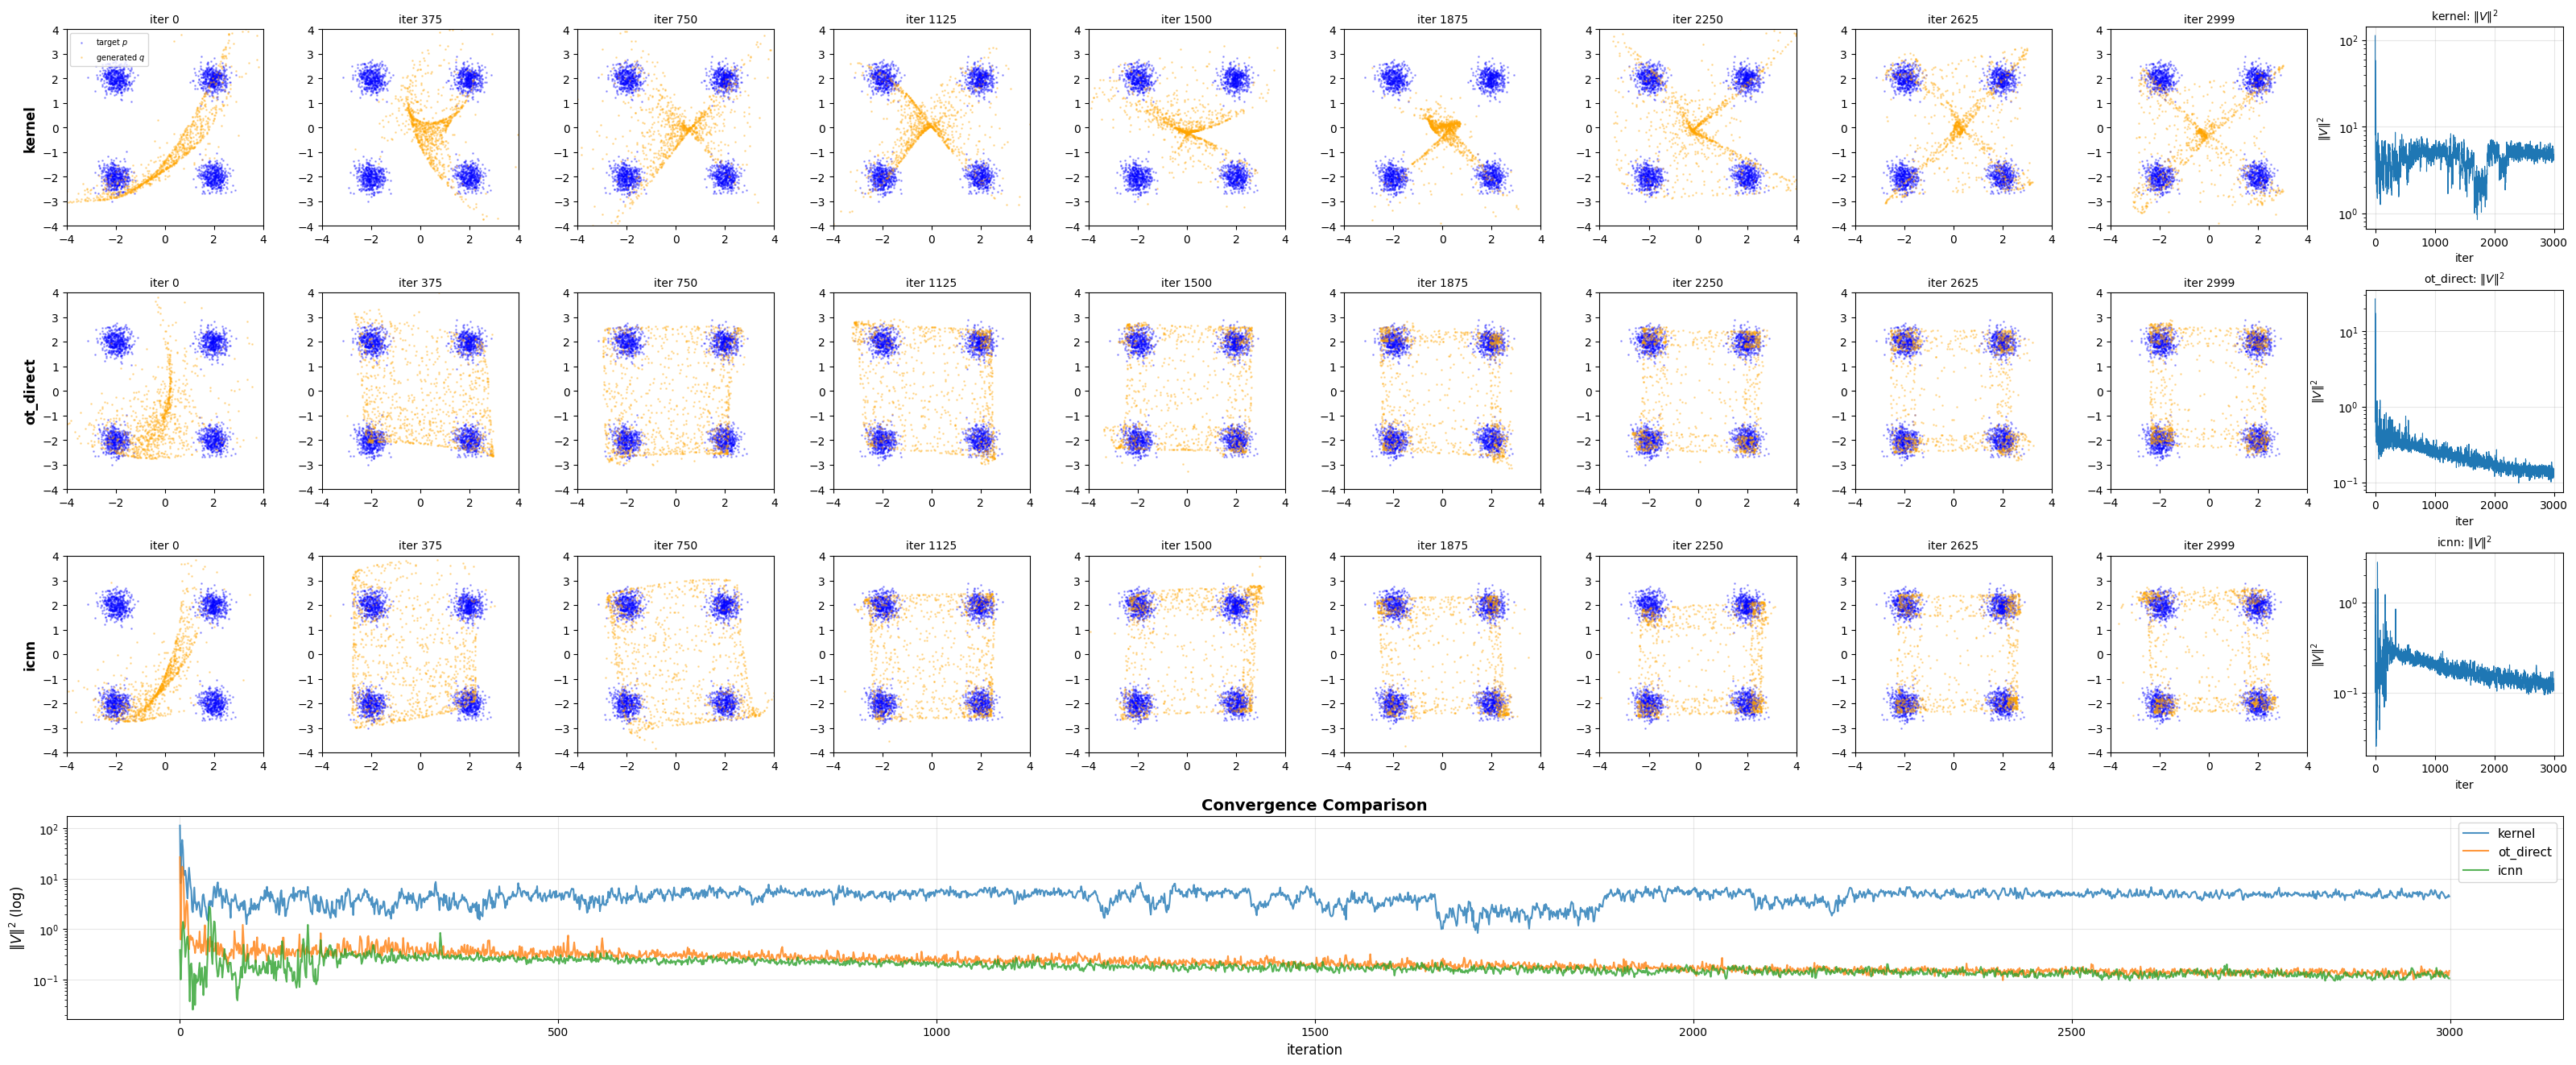

In [18]:
%matplotlib inline

plot_results(results, TARGET, DEVICE, save=True, save_path=SAVE_PATH)

## Next cell to add: Gaussian metrics

Run the helper below after training to turn the current visual result into preliminary quantitative evidence.

In [11]:

# Suggested metrics for four-Gaussian preliminary results.
# Run after `results = [...]` has been computed.

def four_gaussian_metrics(samples, radius=0.75):
    """Simple held-out diagnostics for the four-Gaussian target."""
    x = torch.as_tensor(samples, dtype=torch.float32)
    centers = torch.tensor([[-2., -2.], [-2., 2.], [2., -2.], [2., 2.]])
    d = torch.cdist(x, centers)
    nearest = d.argmin(dim=1)
    min_dist = d.min(dim=1).values

    counts = torch.bincount(nearest, minlength=4).float()
    mass = counts / counts.sum().clamp_min(1.0)
    close_mass = torch.stack([
        ((nearest == k) & (min_dist < radius)).float().mean()
        for k in range(4)
    ])
    captured = int((close_mass > 0.02).sum().item())
    off_manifold = float((min_dist >= radius).float().mean().item())

    return {
        "captured_modes": captured,
        "mass_per_mode": mass.tolist(),
        "close_mass_per_mode": close_mass.tolist(),
        "off_manifold_frac": off_manifold,
        "mean_nearest_center_dist": float(min_dist.mean().item()),
    }

for res in results:
    final_samples = res["snapshots"][-1][1]
    print(res["method"], four_gaussian_metrics(final_samples))


kernel {'captured_modes': 4, 'mass_per_mode': [0.44600000977516174, 0.1889999955892563, 0.18199999630451202, 0.18299999833106995], 'close_mass_per_mode': [0.0729999989271164, 0.06300000101327896, 0.035999998450279236, 0.054999999701976776], 'off_manifold_frac': 0.7730000019073486, 'mean_nearest_center_dist': 1.4966615438461304}
ot_direct {'captured_modes': 4, 'mass_per_mode': [0.2809999883174896, 0.2460000067949295, 0.24199999868869781, 0.23100000619888306], 'close_mass_per_mode': [0.19599999487400055, 0.14900000393390656, 0.16599999368190765, 0.16300000250339508], 'off_manifold_frac': 0.32600000500679016, 'mean_nearest_center_dist': 0.7126175761222839}
icnn {'captured_modes': 4, 'mass_per_mode': [0.2460000067949295, 0.2549999952316284, 0.27000001072883606, 0.2290000021457672], 'close_mass_per_mode': [0.17299999296665192, 0.125, 0.16599999368190765, 0.10000000149011612], 'off_manifold_frac': 0.4359999895095825, 'mean_nearest_center_dist': 0.8382043838500977}


## ICNN width/depth ablation

This section answers: **when we increase ICNN expressiveness, what happens to the drift norm / loss?**

Important: the drift norm alone can be misleading because the ICNN starts near the identity map, so a very weak ICNN can sometimes produce artificially small drift. Therefore the ablation logs three quantities:

1. `v_norm`: the actual generator loss, i.e. mean squared drift `||V||² = ||∇ψ(x)-x||²`.
2. `target_v_norm`: the direct Sinkhorn barycentric displacement norm `||y_bar - x||²`.
3. `inner_loss`: how well the ICNN fits the Sinkhorn target, i.e. `||∇ψ(x)-y_bar||²`.

Interpretation:
- Good case: `v_norm` decreases and `inner_loss` decreases.
- Capacity bottleneck: small/narrow ICNN has high `inner_loss`.
- Suspicious case: `v_norm` is tiny but `inner_loss` and `target_v_norm` are high. This may mean the ICNN is underfitting and outputting near-identity drift, not actually solving transport.

In [ ]:
import os, time
import pandas as pd

# count_parameters and the NPF classes are imported at the top of the notebook.


def train_npf_architecture(
    width=128,
    depth=3,
    target="four_gaussians",
    num_iters=1000,
    batch_size=512,
    lr=3e-4,
    inner_steps=10,
    seed=42,
    device=None,
    sinkhorn_reg=0.05,
    inner_lr=NPF_INNER_LR,
    init_eps=NPF_INIT_EPS,
    outer_rank=NPF_OUTER_RANK,
    inner_rank=NPF_INNER_RANK,
    activation=NPF_ACTIVATION,
    softplus_beta=NPF_SOFTPLUS_BETA,
    grad_clip=NPF_GRAD_CLIP,
    log_every=None,
):
    """Train only the NPF method for one architecture.

    width/depth convention:
        hidden_dims = [width] * depth

    Returns a dictionary with full curves and summary metrics.
    """
    if device is None:
        device = DEVICE
    device = torch.device(device)

    hidden_dims = [int(width)] * int(depth)

    # Same generator initialization for all architectures with the same seed.
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    samplers = dict(
        bimodal=sample_bimodal,
        ring=sample_ring,
        four_gaussians=sample_four_gaussians,
    )
    sample_target = samplers[target]

    gen = ToyGenerator(hidden_dim=256, output_scale=2.0).to(device)
    gen_optim = optim.Adam(gen.parameters(), lr=lr)

    npf_drift = NPFDriftField(
        dim=2,
        hidden_dims=hidden_dims,
        outer_rank=outer_rank,
        inner_rank=inner_rank,
        activation=activation,
        softplus_beta=softplus_beta,
        init_eps=init_eps,
        inner_steps=inner_steps,
        inner_lr=inner_lr,
        grad_clip=grad_clip,
        sinkhorn_reg=sinkhorn_reg,
        sinkhorn_iters=100,
        sinkhorn_target_fn=make_npf_target_fn(sinkhorn_reg),
        init_mode="identity",
    ).to(device)

    # Reset RNG after architecture-dependent NPF initialization.
    torch.manual_seed(seed + 10_000)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed + 10_000)

    v_norms, losses, inner_losses, target_v_norms, fit_ratios = [], [], [], [], []

    if log_every is None:
        log_every = max(1, num_iters // 5)

    t0 = time.time()
    for it in range(num_iters):
        eps = torch.randn(batch_size, 2, device=device)
        y_pos = sample_target(batch_size, device)
        x_gen = gen(eps)

        V, stats = npf_drift.compute_V_with_stats(x_gen, y_pos)

        target_pts = (x_gen.detach() + V).detach()
        loss = ((x_gen - target_pts) ** 2).mean()

        gen_optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
        gen_optim.step()

        v_norm = (V ** 2).mean().item()
        losses.append(loss.item())
        v_norms.append(v_norm)
        inner_losses.append(stats["inner_loss"])
        target_v_norms.append(stats["target_v_norm"])
        fit_ratios.append(stats["fit_ratio"])

        if it % log_every == 0 or it == num_iters - 1:
            print(
                f"[w={width:4d}, d={depth:2d}, seed={seed}] "
                f"iter {it:5d}/{num_iters} | "
                f"||V||²={v_norm:.6f} | "
                f"inner={stats['inner_loss']:.6f} | "
                f"target={stats['target_v_norm']:.6f}"
            )

    elapsed = time.time() - t0
    tail = max(1, num_iters // 10)

    with torch.no_grad():
        final_samples = gen(torch.randn(2000, 2, device=device)).cpu().numpy()

    return {
        "width": int(width),
        "depth": int(depth),
        "hidden_dims": hidden_dims,
        "seed": int(seed),
        "target": target,
        "num_iters": int(num_iters),
        "batch_size": int(batch_size),
        "inner_steps": int(inner_steps),
        "sinkhorn_reg": float(sinkhorn_reg),
        "inner_lr": float(inner_lr),
        "param_count": int(count_parameters(npf_drift.psi)),
        "time_sec": float(elapsed),
        "time_per_iter_sec": float(elapsed / max(1, num_iters)),
        "losses": losses,
        "v_norms": v_norms,
        "inner_losses": inner_losses,
        "target_v_norms": target_v_norms,
        "fit_ratios": fit_ratios,
        "final_samples": final_samples,
        "final_v_norm": float(v_norms[-1]),
        "tail_mean_v_norm": float(np.mean(v_norms[-tail:])),
        "best_v_norm": float(np.min(v_norms)),
        "final_inner_loss": float(inner_losses[-1]),
        "tail_mean_inner_loss": float(np.mean(inner_losses[-tail:])),
        "final_target_v_norm": float(target_v_norms[-1]),
        "tail_mean_target_v_norm": float(np.mean(target_v_norms[-tail:])),
        "final_fit_ratio": float(fit_ratios[-1]),
    }


# Backwards-compatible alias.
train_icnn_architecture = train_npf_architecture


def run_width_depth_ablation(
    widths=(32, 64, 128, 256),
    depths=(1, 2, 3, 4),
    seeds=(42,),
    target="four_gaussians",
    num_iters=1000,
    batch_size=512,
    inner_steps=10,
    lr=3e-4,
    sinkhorn_reg=0.05,
    inner_lr=NPF_INNER_LR,
    init_eps=NPF_INIT_EPS,
    outer_rank=NPF_OUTER_RANK,
    activation=NPF_ACTIVATION,
    softplus_beta=NPF_SOFTPLUS_BETA,
    device=None,
    save_dir="results/icnn_width_depth_ablation",
):
    """Run the architecture ablation across (widths × depths × seeds)."""
    os.makedirs(save_dir, exist_ok=True)
    records, runs = [], []

    total = len(widths) * len(depths) * len(seeds)
    job = 0

    for depth in depths:
        for width in widths:
            for seed in seeds:
                job += 1
                print("\n" + "=" * 80)
                print(f"Ablation job {job}/{total}: width={width}, depth={depth}, seed={seed}")
                print("=" * 80)

                run = train_npf_architecture(
                    width=width,
                    depth=depth,
                    target=target,
                    num_iters=num_iters,
                    batch_size=batch_size,
                    lr=lr,
                    inner_steps=inner_steps,
                    seed=seed,
                    device=device,
                    sinkhorn_reg=sinkhorn_reg,
                    inner_lr=inner_lr,
                    init_eps=init_eps,
                    outer_rank=outer_rank,
                    activation=activation,
                    softplus_beta=softplus_beta,
                )

                runs.append(run)
                records.append({
                    "width": run["width"],
                    "depth": run["depth"],
                    "seed": run["seed"],
                    "param_count": run["param_count"],
                    "final_v_norm": run["final_v_norm"],
                    "tail_mean_v_norm": run["tail_mean_v_norm"],
                    "best_v_norm": run["best_v_norm"],
                    "final_inner_loss": run["final_inner_loss"],
                    "tail_mean_inner_loss": run["tail_mean_inner_loss"],
                    "final_target_v_norm": run["final_target_v_norm"],
                    "tail_mean_target_v_norm": run["tail_mean_target_v_norm"],
                    "final_fit_ratio": run["final_fit_ratio"],
                    "time_sec": run["time_sec"],
                    "time_per_iter_sec": run["time_per_iter_sec"],
                    "num_iters": run["num_iters"],
                    "batch_size": run["batch_size"],
                    "inner_steps": run["inner_steps"],
                    "sinkhorn_reg": run["sinkhorn_reg"],
                    "inner_lr": run["inner_lr"],
                })

                df = pd.DataFrame(records)
                df.to_csv(os.path.join(save_dir, "ablation_summary_partial.csv"), index=False)

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(save_dir, "ablation_summary.csv"), index=False)
    return df, runs


def summarize_ablation(df):
    """Aggregate across seeds. Use `tail_mean_v_norm_mean` as the main number."""
    metrics = [
        "param_count",
        "final_v_norm",
        "tail_mean_v_norm",
        "best_v_norm",
        "final_inner_loss",
        "tail_mean_inner_loss",
        "final_target_v_norm",
        "tail_mean_target_v_norm",
        "final_fit_ratio",
        "time_per_iter_sec",
    ]
    grouped = (
        df.groupby(["depth", "width"])[metrics]
        .agg(["mean", "std"])
        .reset_index()
    )
    grouped.columns = [
        "_".join([str(x) for x in col if x != ""]).strip("_")
        for col in grouped.columns.to_flat_index()
    ]
    grouped = grouped.sort_values("tail_mean_v_norm_mean")
    return grouped


def plot_architecture_heatmap(df, metric="tail_mean_v_norm", save_path=None):
    """Heatmap rows=depth, cols=width. Cell values averaged over seeds."""
    pivot = df.groupby(["depth", "width"])[metric].mean().unstack("width")
    depths = list(pivot.index)
    widths = list(pivot.columns)

    fig, ax = plt.subplots(figsize=(1.4 * len(widths) + 3, 1.0 * len(depths) + 2))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(range(len(widths)))
    ax.set_xticklabels(widths)
    ax.set_yticks(range(len(depths)))
    ax.set_yticklabels(depths)
    ax.set_xlabel("NPF width")
    ax.set_ylabel("NPF depth")
    ax.set_title(metric)
    for i in range(len(depths)):
        for j in range(len(widths)):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.3g}", ha="center", va="center")
    fig.colorbar(im, ax=ax, label=metric)
    fig.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_ablation_curves(runs, metric="v_norms", save_path=None):
    """Plot all curves. For readability, use after a small grid or filter `runs`."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for run in runs:
        label = f"w={run['width']}, d={run['depth']}, seed={run['seed']}"
        y = run[metric]
        ax.semilogy(y, linewidth=1.0, alpha=0.85, label=label)

    ax.set_xlabel("iteration")
    ylabel = {
        "v_norms": r"$\|V\|^2$ / generator loss",
        "inner_losses": r"NPF inner loss $\|\nabla\psi(x)-\bar y\|^2$",
        "target_v_norms": r"direct OT target drift $\|\bar y-x\|^2$",
        "fit_ratios": r"$\|V_{NPF}\|^2 / \|\bar y-x\|^2$",
    }.get(metric, metric)
    ax.set_ylabel(ylabel)
    ax.set_title(f"NPF architecture ablation: {metric}")
    ax.grid(True, alpha=0.3)
    if len(runs) <= 12:
        ax.legend(fontsize=8)
    fig.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return fig, ax


### Run the ablation

Start with the quick grid below. Once it works, change to the report-quality grid in the comments.

Recommended interpretation:
- Main number: `tail_mean_v_norm`, because final iteration alone is noisy.
- Sanity number: `tail_mean_inner_loss`, because it tells you if the ICNN is actually fitting the Sinkhorn target.
- Efficiency number: `time_per_iter_sec`, because larger width/depth may lower drift but become too slow.

In [ ]:
# Quick first pass: should be enough to see the trend.
ABLATION_WIDTHS = [32, 64, 128]
ABLATION_DEPTHS = [1, 2, 4]
ABLATION_SEEDS = [42]
ABLATION_ITERS = 600

# Report-quality version:
# ABLATION_WIDTHS = [32, 64, 128, 256]
# ABLATION_DEPTHS = [1, 2, 3, 4]
# ABLATION_SEEDS = [0, 1, 2, 3, 4]
# ABLATION_ITERS = 3000

ablation_df, ablation_runs = run_width_depth_ablation(
    widths=ABLATION_WIDTHS,
    depths=ABLATION_DEPTHS,
    seeds=ABLATION_SEEDS,
    target=TARGET,
    num_iters=ABLATION_ITERS,
    batch_size=BATCH_SIZE,
    inner_steps=INNER_STEPS,
    lr=LR,
    sinkhorn_reg=SINKHORN_REG,
    inner_lr=NPF_INNER_LR,
    init_eps=NPF_INIT_EPS,
    outer_rank=NPF_OUTER_RANK,
    activation=NPF_ACTIVATION,
    softplus_beta=NPF_SOFTPLUS_BETA,
    device=DEVICE,
)

ablation_df

In [14]:
ablation_summary = summarize_ablation(ablation_df)
ablation_summary

,depth,width,param_count_mean,param_count_std,final_v_norm_mean,final_v_norm_std,tail_mean_v_norm_mean,tail_mean_v_norm_std,best_v_norm_mean,best_v_norm_std,...,tail_mean_inner_loss_mean,tail_mean_inner_loss_std,final_target_v_norm_mean,final_target_v_norm_std,tail_mean_target_v_norm_mean,tail_mean_target_v_norm_std,final_fit_ratio_mean,final_fit_ratio_std,time_per_iter_sec_mean,time_per_iter_sec_std
6,4,32,3493.0,NaN,0.034261,NaN,0.035996,NaN,0.000835,NaN,...,0.011021,NaN,0.015538,NaN,0.031522,NaN,2.204978,NaN,0.129183,NaN
2,1,128,517.0,NaN,0.029972,NaN,0.044149,NaN,0.000962,NaN,...,0.011332,NaN,0.030325,NaN,0.039724,NaN,0.988367,NaN,0.073410,NaN
0,1,32,133.0,NaN,0.115528,NaN,0.173522,NaN,0.009244,NaN,...,0.136385,NaN,0.265598,NaN,0.306182,NaN,0.434973,NaN,0.072521,NaN
5,2,128,17285.0,NaN,0.163852,NaN,0.202409,NaN,0.008085,NaN,...,0.122374,NaN,0.243784,NaN,0.316101,NaN,0.672121,NaN,0.102605,NaN
4,2,64,4549.0,NaN,0.250226,NaN,0.236672,NaN,0.004863,NaN,...,0.124583,NaN,0.294705,NaN,0.356483,NaN,0.849075,NaN,0.096611,NaN
8,4,128,50821.0,NaN,0.235461,NaN,0.237855,NaN,0.020479,NaN,...,0.130398,NaN,0.331696,NaN,0.371880,NaN,0.709868,NaN,0.124658,NaN
7,4,64,13125.0,NaN,0.272561,NaN,0.257859,NaN,0.008085,NaN,...,0.059081,NaN,0.353101,NaN,0.319955,NaN,0.771908,NaN,0.121576,NaN
3,2,32,1253.0,NaN,0.243962,NaN,0.284284,NaN,0.003967,NaN,...,0.057840,NaN,0.261889,NaN,0.338510,NaN,0.931548,NaN,0.092560,NaN
1,1,64,261.0,NaN,0.142146,NaN,0.293185,NaN,0.000915,NaN,...,0.108391,NaN,0.354123,NaN,0.360314,NaN,0.401403,NaN,0.076237,NaN


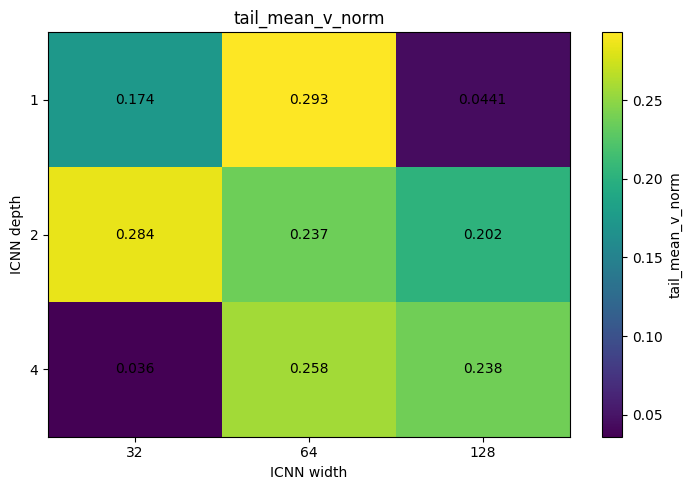

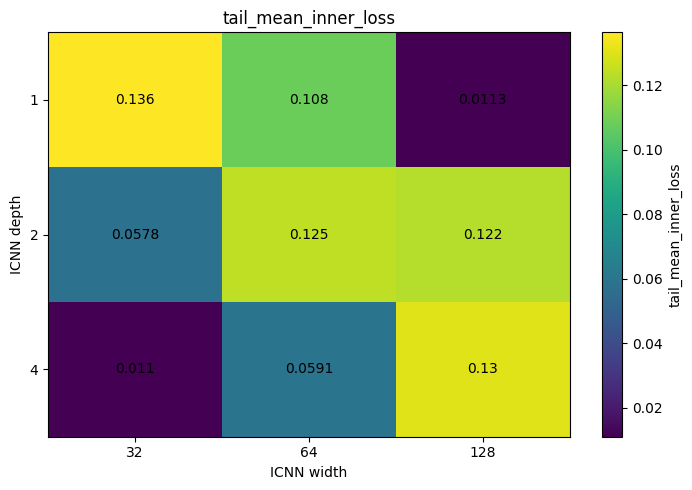

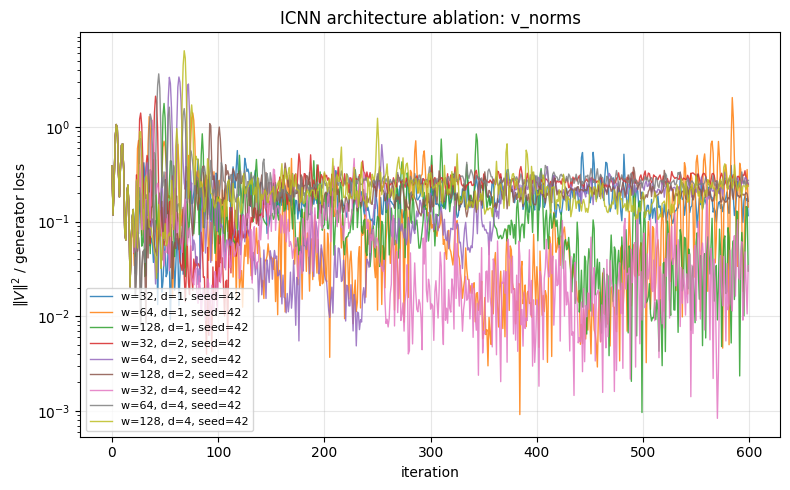

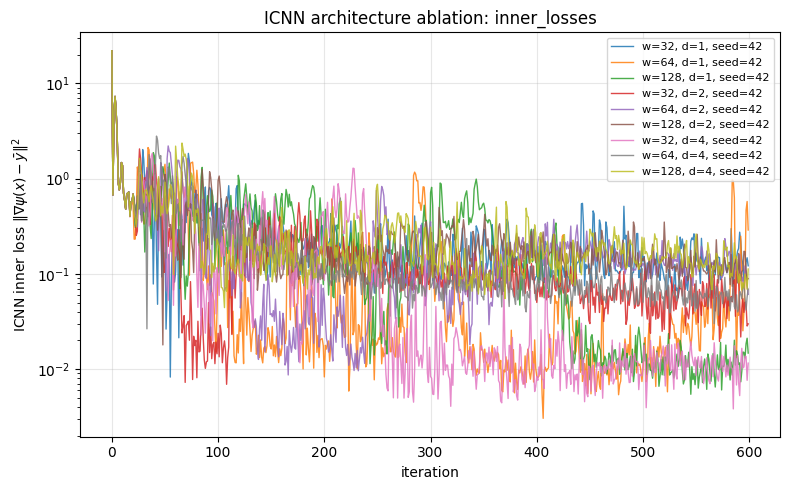

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'ICNN architecture ablation: inner_losses'}, xlabel='iteration', ylabel='ICNN inner loss $\\|\\nabla\\psi(x)-\\bar y\\|^2$'>)

In [17]:
plot_architecture_heatmap(
    ablation_df,
    metric="tail_mean_v_norm",
    save_path="results/icnn_width_depth_ablation/heatmap_tail_mean_v_norm.png",
)

plot_architecture_heatmap(
    ablation_df,
    metric="tail_mean_inner_loss",
    save_path="results/icnn_width_depth_ablation/heatmap_tail_mean_inner_loss.png",
)

plot_ablation_curves(
    ablation_runs,
    metric="v_norms",
    save_path="results/icnn_width_depth_ablation/curves_v_norms.png",
)

plot_ablation_curves(
    ablation_runs,
    metric="inner_losses",
    save_path="results/icnn_width_depth_ablation/curves_inner_losses.png",
)